In [1]:
import json
import boto3
import pandas as pd
import numpy as np
import awswrangler as wr
from sqlalchemy import create_engine

import matplotlib.pyplot as plt
plt.style.use("ggplot")

In [3]:
client = boto3.client("secretsmanager", region_name="us-east-1")
secret = client.get_secret_value(SecretId="itam/rds/northwind/credentials")
creds = json.loads(secret["SecretString"])

{
    "username": creds["username"],
    "dbname": creds.get("dbname"),
    "port": creds.get("port")
}

{'username': 'itam', 'dbname': 'flights', 'port': '5432'}

In [6]:
RDS_REPLICA_ENDPOINT = "itam-northwind-replica-995371347105.ciheg4as0flj.us-east-1.rds.amazonaws.com"
DB_NAME = "flights"

engine = create_engine(
    f"postgresql+psycopg2://{creds['username']}:{creds['password']}@{RDS_REPLICA_ENDPOINT}:{creds['port']}/{DB_NAME}"
)

In [7]:
pd.read_sql("SELECT 1 AS test;", engine)

,test
0,1


In [8]:
query_p1 = """
SELECT
    origin_airport,
    destination_airport,
    COUNT(*) AS total_flights
FROM flights
GROUP BY origin_airport, destination_airport
ORDER BY total_flights DESC
LIMIT 10;
"""

df_p1 = pd.read_sql(query_p1, engine)
df_p1

,origin_airport,destination_airport,total_flights
0,LAX,JFK,1218
1,JFK,LAX,1217
2,SFO,LAX,1186
3,LAX,SFO,1172
4,LAS,LAX,1018
5,LAX,LAS,987
6,LGA,ORD,917
7,ORD,LGA,908
8,HNL,OGG,874
9,OGG,HNL,873


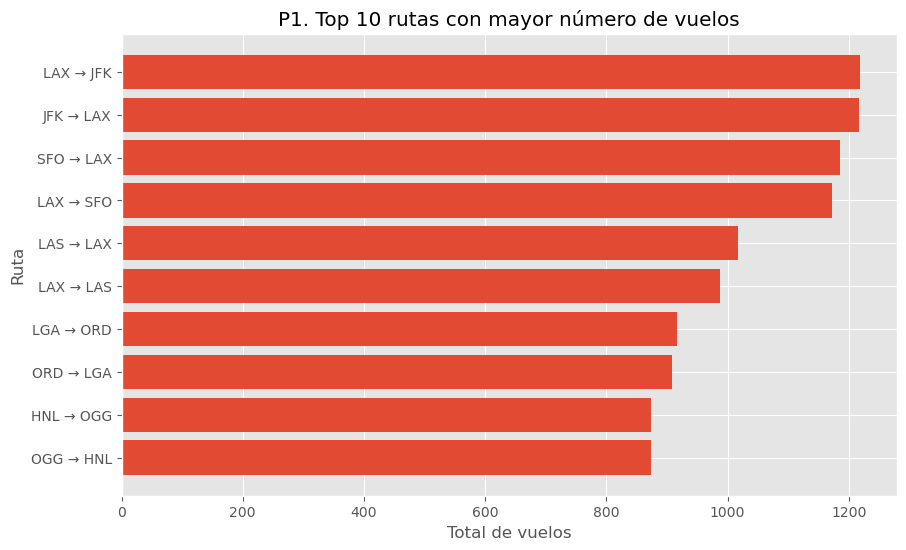

In [9]:
df_p1["route"] = df_p1["origin_airport"] + " → " + df_p1["destination_airport"]

plt.figure(figsize=(10, 6))
plt.barh(df_p1["route"], df_p1["total_flights"])
plt.xlabel("Total de vuelos")
plt.ylabel("Ruta")
plt.title("P1. Top 10 rutas con mayor número de vuelos")
plt.gca().invert_yaxis()
plt.show()

In [10]:
query_p2 = """
SELECT
    airline,
    COUNT(*) AS total_flights,
    SUM(CASE WHEN cancelled = 1 THEN 1 ELSE 0 END) AS total_cancelled,
    100.0 * SUM(CASE WHEN cancelled = 1 THEN 1 ELSE 0 END) / COUNT(*) AS cancelled_pct
FROM flights
GROUP BY airline
ORDER BY cancelled_pct DESC, total_flights DESC
LIMIT 5;
"""

df_p2 = pd.read_sql(query_p2, engine)
df_p2

,airline,total_flights,total_cancelled,cancelled_pct
0,MQ,31896,3136,9.831954
1,B6,23062,1479,6.413147
2,EV,52965,2523,4.763523
3,US,35591,1268,3.562698
4,UA,40873,1424,3.483963


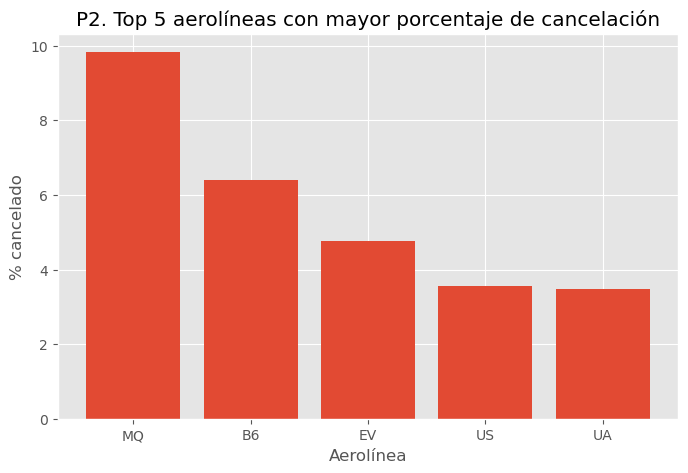

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(df_p2["airline"], df_p2["cancelled_pct"])
plt.xlabel("Aerolínea")
plt.ylabel("% cancelado")
plt.title("P2. Top 5 aerolíneas con mayor porcentaje de cancelación")
plt.show()

In [12]:
query_p3 = """
SELECT
    cancellation_reason,
    COUNT(*) AS total_cancelled
FROM flights
WHERE cancellation_reason IS NOT NULL
GROUP BY cancellation_reason
ORDER BY total_cancelled DESC;
"""

df_p3 = pd.read_sql(query_p3, engine)
df_p3

,cancellation_reason,total_cancelled
0,B,10630
1,A,3230
2,C,2962
3,D,2


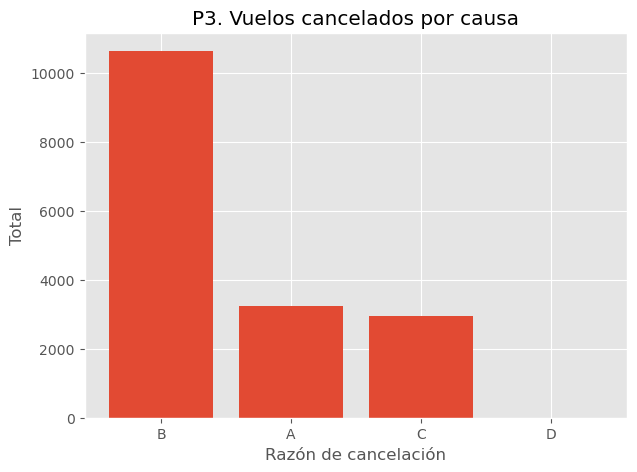

In [13]:
plt.figure(figsize=(7, 5))
plt.bar(df_p3["cancellation_reason"], df_p3["total_cancelled"])
plt.xlabel("Razón de cancelación")
plt.ylabel("Total")
plt.title("P3. Vuelos cancelados por causa")
plt.show()

In [14]:
query_p4 = """
SELECT
    month,
    AVG(departure_delay) AS avg_departure_delay
FROM flights
WHERE cancelled = 0
  AND departure_delay > 0
GROUP BY month
ORDER BY month;
"""

df_p4 = pd.read_sql(query_p4, engine)
df_p4

,month,avg_departure_delay
0,1,32.571225
1,2,42.306487


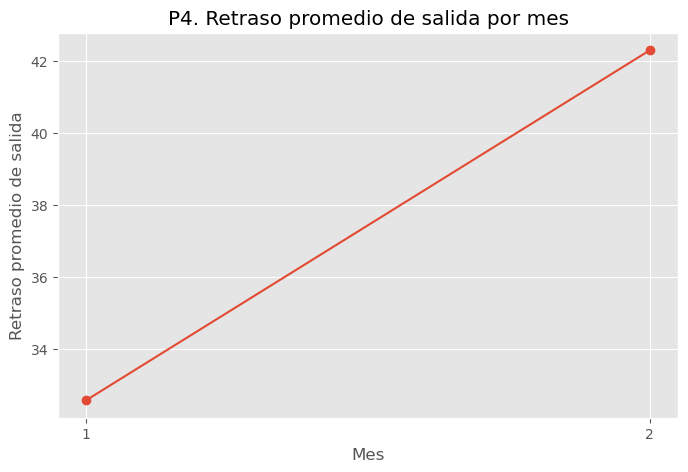

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(df_p4["month"], df_p4["avg_departure_delay"], marker="o")
plt.xlabel("Mes")
plt.ylabel("Retraso promedio de salida")
plt.title("P4. Retraso promedio de salida por mes")
plt.xticks(df_p4["month"])
plt.show()

In [16]:
query_p5 = """
SELECT
    origin_airport,
    SUM(COALESCE(weather_delay, 0)) AS total_weather_delay_minutes
FROM flights
GROUP BY origin_airport
ORDER BY total_weather_delay_minutes DESC
LIMIT 10;
"""

df_p5 = pd.read_sql(query_p5, engine)
df_p5

,origin_airport,total_weather_delay_minutes
0,ORD,102749.0
1,JFK,20542.0
2,LGA,13620.0
3,ATL,12562.0
4,DTW,12361.0
5,BOS,11361.0
6,DEN,8359.0
7,DCA,8188.0
8,PHX,7878.0
9,DFW,6870.0


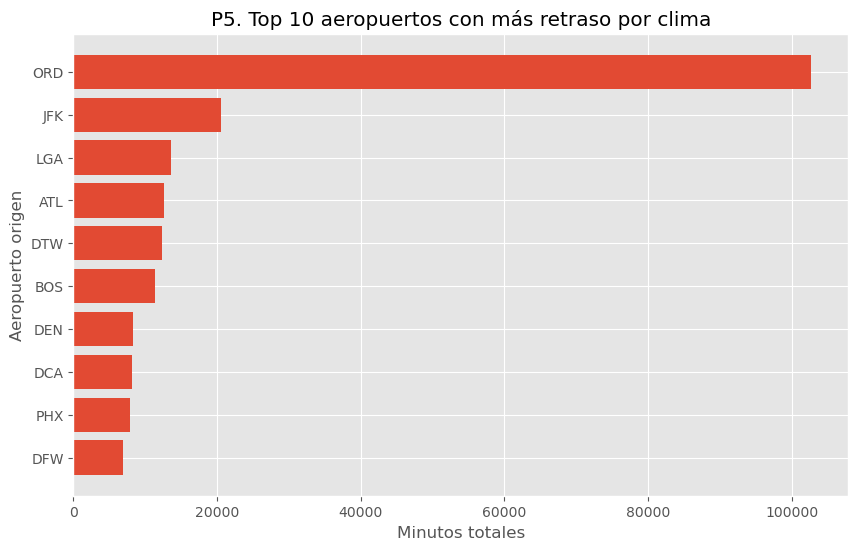

In [17]:
plt.figure(figsize=(10, 6))
plt.barh(df_p5["origin_airport"], df_p5["total_weather_delay_minutes"])
plt.xlabel("Minutos totales")
plt.ylabel("Aeropuerto origen")
plt.title("P5. Top 10 aeropuertos con más retraso por clima")
plt.gca().invert_yaxis()
plt.show()

In [18]:
query_w1 = """
WITH ranked_flights AS (
    SELECT
        airline,
        flight_number,
        origin_airport,
        destination_airport,
        arrival_delay,
        RANK() OVER (
            PARTITION BY airline
            ORDER BY arrival_delay DESC NULLS LAST
        ) AS rnk
    FROM flights
)
SELECT
    airline,
    flight_number,
    origin_airport,
    destination_airport,
    arrival_delay
FROM ranked_flights
WHERE rnk = 1
ORDER BY airline;
"""

df_w1 = pd.read_sql(query_w1, engine)
df_w1

,airline,flight_number,origin_airport,destination_airport,arrival_delay
0,AA,1322,BHM,DFW,1971.0
1,AS,455,LAX,SEA,451.0
2,B6,576,MSY,JFK,502.0
3,DL,1435,MIA,MSP,1174.0
4,EV,2567,SHV,DFW,723.0
5,F9,1256,ORD,MIA,686.0
6,HA,51,JFK,HNL,1013.0
7,MQ,2962,CLL,DFW,788.0
8,NK,728,TPA,ORD,570.0
9,OO,2642,CHO,ORD,953.0


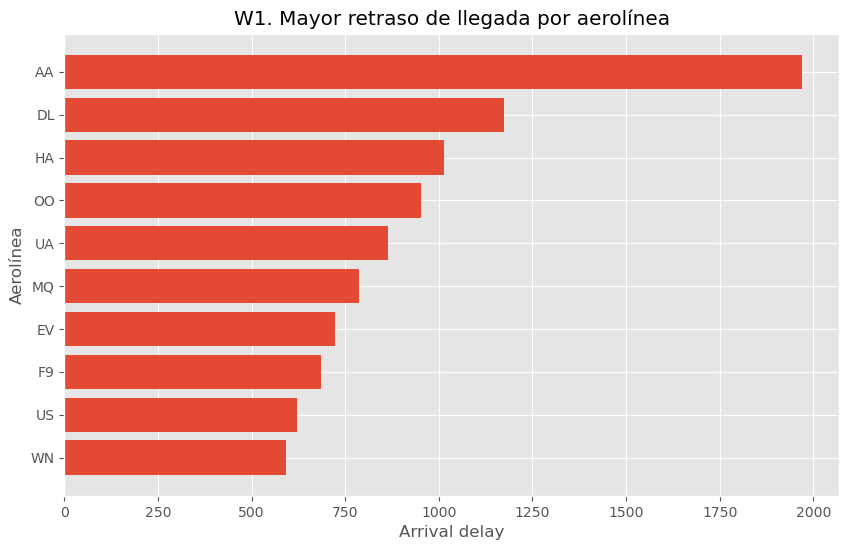

In [19]:
df_w1_plot = df_w1.sort_values("arrival_delay", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(df_w1_plot["airline"], df_w1_plot["arrival_delay"])
plt.xlabel("Arrival delay")
plt.ylabel("Aerolínea")
plt.title("W1. Mayor retraso de llegada por aerolínea")
plt.gca().invert_yaxis()
plt.show()

In [20]:
query_w3 = """
WITH ordered_flights AS (
    SELECT
        year,
        month,
        day,
        origin_airport,
        flight_number,
        airline,
        destination_airport,
        scheduled_departure,
        ROW_NUMBER() OVER (
            PARTITION BY year, month, day, origin_airport
            ORDER BY scheduled_departure ASC
        ) AS rn
    FROM flights
    WHERE year = 2015
      AND month = 1
      AND day = 1
      AND origin_airport = 'LAX'
)
SELECT
    flight_number,
    airline,
    destination_airport,
    scheduled_departure
FROM ordered_flights
WHERE rn <= 5
ORDER BY rn;
"""

df_w3 = pd.read_sql(query_w3, engine)
df_w3

,flight_number,airline,destination_airport,scheduled_departure
0,2336,AA,PBI,10
1,258,AA,MIA,20
2,2013,US,CLT,30
3,1434,DL,MSP,35
4,115,AA,MIA,105


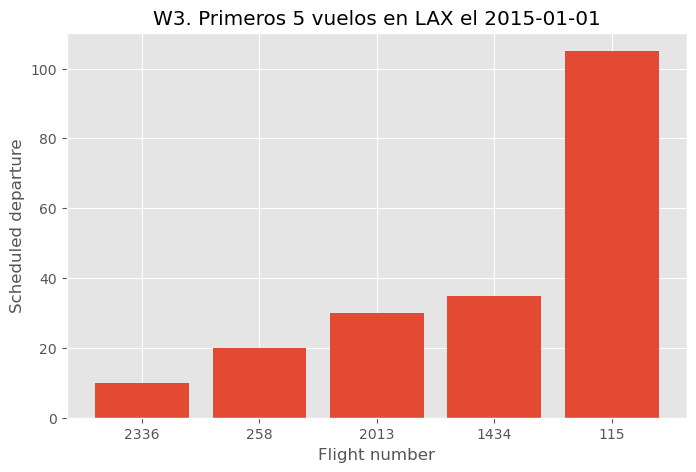

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(df_w3["flight_number"].astype(str), df_w3["scheduled_departure"])
plt.xlabel("Flight number")
plt.ylabel("Scheduled departure")
plt.title("W3. Primeros 5 vuelos en LAX el 2015-01-01")
plt.show()

In [22]:
query_w2 = """
SELECT
    month,
    SUM(total_flights) AS total_flights,
    LAG(SUM(total_flights)) OVER (ORDER BY month) AS prev_month_flights,
    SUM(total_flights) - LAG(SUM(total_flights)) OVER (ORDER BY month) AS abs_change,
    100.0 * (
        SUM(total_flights) - LAG(SUM(total_flights)) OVER (ORDER BY month)
    ) / NULLIF(LAG(SUM(total_flights)) OVER (ORDER BY month), 0) AS pct_change
FROM flights_silver.flights_monthly
GROUP BY month
ORDER BY month;
"""

df_w2 = wr.athena.read_sql_query(
    sql=query_w2,
    database="flights_silver"
)

df_w2

2026-04-16 06:45:49,316	WARNING services.py:2070 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 409956352 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=0.71gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-04-16 06:45:50,597	INFO worker.py:1852 -- Started a local Ray instance.


,month,total_flights,prev_month_flights,abs_change,pct_change
0,1,469968,<NA>,<NA>,NaN
1,2,429191,469968,-40777,-8.676548
2,3,504312,429191,75121,17.502930
3,4,485151,504312,-19161,-3.799434
4,5,496993,485151,11842,2.440890
5,6,503897,496993,6904,1.389154
6,7,520718,503897,16821,3.338182
7,8,510536,520718,-10182,-1.955377
8,9,464946,510536,-45590,-8.929831
9,10,486165,464946,21219,4.563756


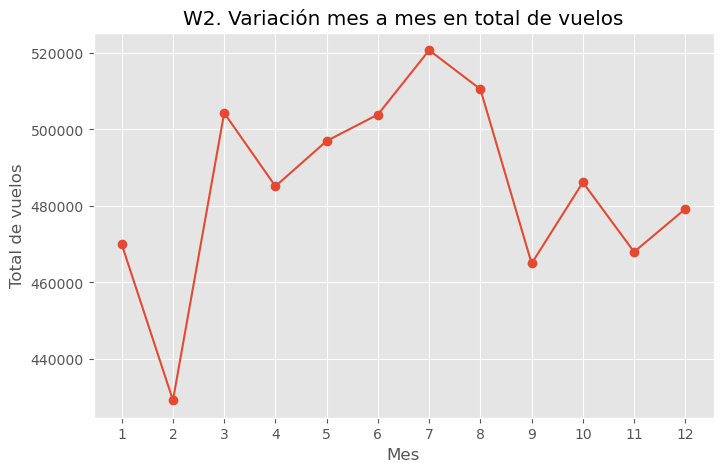

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(df_w2["month"], df_w2["total_flights"], marker="o")
plt.xlabel("Mes")
plt.ylabel("Total de vuelos")
plt.title("W2. Variación mes a mes en total de vuelos")
plt.xticks(df_w2["month"])
plt.show()